# **DEPENDENCIAS**

In [28]:
!pip install -U keras-nlp keras
!pip install chromadb
!pip install deep_translator
!pip install mlflow -q

# **CARGA DEL DATASET**

In [29]:
import pandas as pd

# CARGAR EL DATASET
df = pd.read_csv("Symptom2Disease.csv")

# MOSTRAR INFORMACIÓN DE LOS DATOS
print("- - - - - - - - - - - - - - Resumen - - - - - - - - - - - - - -")
display(df.head(10))
print("\n")

print("- Forma -")
display(df.shape)
print("\n")

- - - - - - - - - - - - - - Resumen - - - - - - - - - - - - - -


,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."
5,5,Psoriasis,The skin on my palms and soles is thickened an...
6,6,Psoriasis,"The skin around my mouth, nose, and eyes is re..."
7,7,Psoriasis,My skin is very sensitive and reacts easily to...
8,8,Psoriasis,I have noticed a sudden peeling of skin at dif...
9,9,Psoriasis,The skin on my genitals is red and inflamed. I...




- Forma -


(1200, 3)

# **LIMPIEZA DE DATOS**

#### LIMPIEZA BÁSICA

In [30]:
# ELIMINAR ESPACIOS EN BLANCO
df["label"] = df["label"].str.strip()

# ELIMINAR DUPLICADOS
df.drop_duplicates(subset="text", inplace=True)

# MOSTRAR VALORES NULOS
print("Valores nulos:", df.isnull().sum())

Valores nulos: Unnamed: 0    0
label         0
text          0
dtype: int64


#### DATAFRAME FINAL

In [31]:
columnas_a_mantener = ["text", "label"]

df_final = df[columnas_a_mantener].copy()

df_final.columns = ["text", "label"]

df_final.to_csv("Symptom2Disease_final.csv", index=False)

display(df_final.head(20))

,text,label
0,I have been experiencing a skin rash on my arm...,Psoriasis
1,"My skin has been peeling, especially on my kne...",Psoriasis
2,I have been experiencing joint pain in my fing...,Psoriasis
3,"There is a silver like dusting on my skin, esp...",Psoriasis
4,"My nails have small dents or pits in them, and...",Psoriasis
5,The skin on my palms and soles is thickened an...,Psoriasis
6,"The skin around my mouth, nose, and eyes is re...",Psoriasis
7,My skin is very sensitive and reacts easily to...,Psoriasis
8,I have noticed a sudden peeling of skin at dif...,Psoriasis
9,The skin on my genitals is red and inflamed. I...,Psoriasis


# **EJECUTAR CELDAS DE R**

In [32]:
# EJECUTAR CELDAS DE R
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


# **ANÁLISIS ESTADÍSTICO EN R (EDA)**

In [33]:
%%R
library(tidyverse)
library(ggplot2)

# CARGAR EL DATASET
df <- read.csv("Symptom2Disease_final.csv")

# RESUMEN ESTADÍSTICO
print(summary(df))

     text              label          
 Length:1153        Length:1153       
 Class :character   Class :character  
 Mode  :character   Mode  :character  


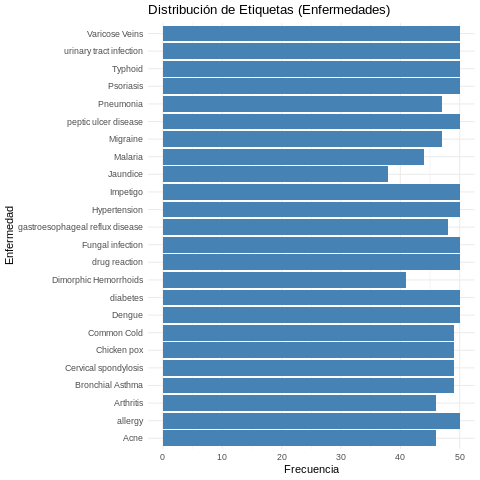

In [34]:
%%R
# DISTRIBUCIÓN DE ENFERMEDADES
p1 <- ggplot(df, aes(x = label)) +
       geom_bar(fill = "steelblue") +
       coord_flip() +
       labs(title = "Distribución de Etiquetas (Enfermedades)",
            x = "Enfermedad",
            y = "Frecuencia") +
       theme_minimal()

print(p1)

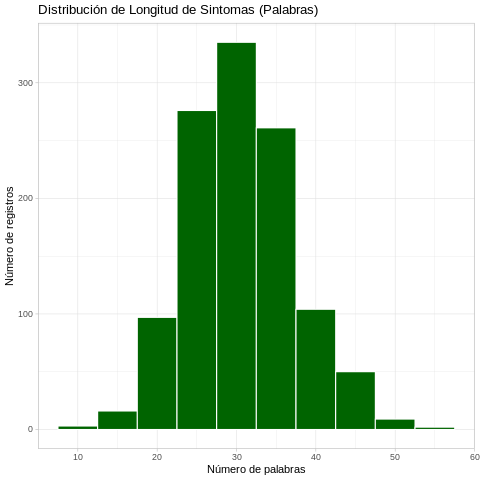

In [35]:
%%R
# ANÁLISIS DE LONGITUD DE TEXTO
df$numero_palabras <- sapply(strsplit(as.character(df$text), " "), length)

p2 <- ggplot(df, aes(x = numero_palabras)) +
       geom_histogram(binwidth = 5, fill = "darkgreen", color = "white") +
       labs(title = "Distribución de Longitud de Sintomas (Palabras)",
            x = "Número de palabras",
            y = "Número de registros") +
       theme_light()

print(p2)

In [36]:
%%R
# GUARDAR LOS GRÁFICOS
ggsave("distribución_enfermedades.png", plot = p1, width = 10, height = 6, dpi = 300)
ggsave("longitud_textos.png", plot = p2, width = 10, height = 6, dpi = 300)

# **MODELO**

#### INSTALACIÓN Y CONFIGURACIÓN INICIAL

In [37]:
# PREPARAR ENTORNO
'''
PROBLEMA:
AL TRABAJAR EN GOOGLE COLAB CON PYTHON 3.12, LA LIBRERÍA TRANSFORMERS NO LOGRA
REGISTRAR LAS CLASES DE TFAUTOMODEL DEBIDO A LA TRANSICIÓN HACIA KERAS 3.

SOLUCIÓN:
CARGAR EL MODELO EN SU FORMATO NATIVO (PYTORCH) Y DEJAR QUE KERAS LO GESTIONE.
'''

import os
os.environ["KERAS_BACKEND"] = "tensorflow"


import keras_nlp
import keras
import tensorflow as tf
import numpy as np
import chromadb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# OPTIMIZACIÓN DE VRAM
tf.keras.mixed_precision.set_global_policy('mixed_float16')

print("Entorno configurado con KerasNLP y backend TensorFlow")

Entorno configurado con KerasNLP y backend TensorFlow


#### CARGA DE DATOS Y SPLIT

In [38]:
# CODIFICAR LAS ETIQUETAS MÉDICAS
df = pd.read_csv("Symptom2Disease_final.csv")

label_encoder = LabelEncoder()
df['label_idx'] = label_encoder.fit_transform(df['label'])
num_clases = len(label_encoder.classes_)

# SPLIT ESTRATIFICADO - 80% ENTRENAMIENTO, 20% PRUEBA
df_train, df_val = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label_idx']
)

X_train = df_train['text'].values
y_train = df_train['label_idx'].values
X_val = df_val['text'].values
y_val = df_val['label_idx'].values

print(f"Dataset listo: {num_clases} enfermedades detectadas.")

Dataset listo: 24 enfermedades detectadas.


#### INDEXACIÓN VECTORIAL CON CHROMADB

In [39]:
# INICIALIZAR CLIENTE DE CHROMADB
chroma_client = chromadb.Client()
coleccion = chroma_client.create_collection(name="triaje_medico")

coleccion.add(
    documents=df["text"].tolist(),
    metadatas=[{"enfermedad": label} for label in df["label"].tolist()],
    ids=[f"id_{i}" for i in range(len(df))]
)

InternalError: Collection [triaje_medico] already exists

#### GESTIÓN Y SEGUIMIENTO DEL ENTRENAMIENTO (MLOps)

In [40]:
import mlflow
import mlflow.keras

# Crear el 'experimento' y activa el registro automático de hiperparámetros y métricas
mlflow.set_experiment("Triaje_Medico_BERT")
mlflow.keras.autolog()

2026/05/04 20:37:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/04 20:37:07 INFO mlflow.store.db.utils: Updating database tables
2026/05/04 20:37:09 INFO mlflow.tracking.fluent: Experiment with name 'Triaje_Medico_BERT' does not exist. Creating a new experiment.


#### CREACIÓN DEL MODELO DE CLASIFICACIÓN

In [41]:
# CARGAR EL CLASIFICADOR PRE-ENTRENADO
# EL MODELO DESCARGA AUTOMTICAMENTE LOS PESOS Y EL VOCABULARIO
preprocesador = keras_nlp.models.BertPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=64
)

modelo = keras_nlp.models.BertClassifier.from_preset(
    "bert_base_en_uncased",
    preprocessor=preprocesador,
    num_classes=num_clases,
    load_weights=True
)

# COMPILAR MODELO
modelo.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"]
)

# ENTRENAMIENTO
print("Iniciando Fine-tuning...")
history = modelo.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=4
)

100%|██████████| 457/457 [00:00<00:00, 746kB/s]


100%|██████████| 761/761 [00:00<00:00, 1.87MB/s]


100%|██████████| 226k/226k [00:00<00:00, 273kB/s]


100%|██████████| 418M/418M [00:28<00:00, 15.2MB/s]


Iniciando Fine-tuning...


2026/05/04 20:38:24 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '85fd1a438a8f41e8bce27ffbc41e2313', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current keras workflow
2026/05/04 20:38:25 WARNING mlflow.data.tensorflow_dataset: Failed to infer schema for TensorFlow dataset. Exception: Failed to infer schema for tf.data.Dataset. Schemas can only be inferred if the dataset consists of tensors. Ragged tensors, tensor arrays, and other types are not supported. Additionally, datasets with nested tensors are not supported.
2026/05/04 20:38:25 WARNING mlflow.keras.autologging: Failed to log dataset information to MLflow. Reason: 'ascii' codec can't decode byte 0xe2 in position 101: ordinal not in range(128)


Epoch 1/6
231/231 ━━━━━━━━━━━━━━━━━━━━ 145s 269ms/step - accuracy: 0.1453 - loss: 2.9816 - val_accuracy: 0.3896 - val_loss: 2.5818
Epoch 2/6
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.5640 - loss: 2.2611 - val_accuracy: 0.7749 - val_loss: 1.8145
Epoch 3/6
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.8753 - loss: 1.5270 - val_accuracy: 0.9307 - val_loss: 1.1963
Epoch 4/6
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.9729 - loss: 0.9630 - val_accuracy: 0.9437 - val_loss: 0.7680
Epoch 5/6
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9957 - loss: 0.5815 - val_accuracy: 0.9437 - val_loss: 0.4931
Epoch 6/6
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.9978 - loss: 0.3598 - val_accuracy: 0.9567 - val_loss: 0.3409


2026/05/04 20:42:01 WARNING mlflow.keras.autologging: Failed to get model signature, reason: Creating Schema with multiple unnamed TensorSpecs is not supported. Please provide names for each TensorSpec.
2026/05/04 20:42:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 20:42:02 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


#### GUARDAR EL MODELO Y EL LABEL ENCODER

In [42]:
import pickle

modelo.save("asistente_triaje_medico.keras")
print("Modelo guardado.")

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
print("Codificador de etiquetas guardado.")


Modelo guardado.
Codificador de etiquetas guardado.


#### ANÁLISIS DE ERRORES

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 881ms/step
                                 precision    recall  f1-score   support

                           Acne       0.90      1.00      0.95         9
                      Arthritis       1.00      1.00      1.00         9
               Bronchial Asthma       1.00      0.90      0.95        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.75      0.90      0.82        10
                    Common Cold       0.91      1.00      0.95        10
                         Dengue       1.00      0.50      0.67        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00         8
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       0.91      1.00      0.95        10
                       Impetigo       0.90      0.90      0.90        10
                       Jaundice       1.00      1.00      1.00         8
          

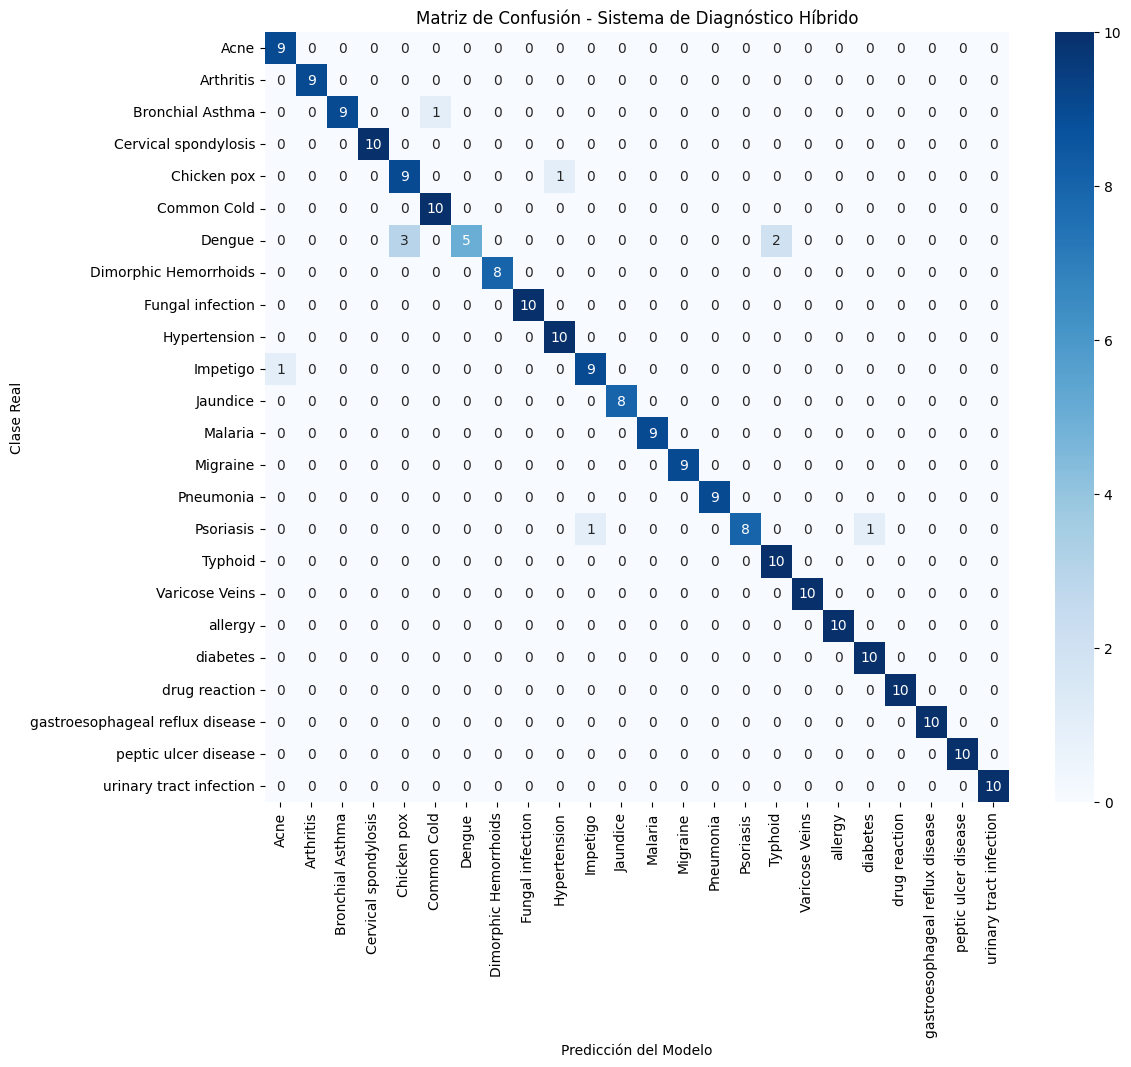

Accuracy Exacto: 0.9567
Recall Exacto: 0.9583
F1-Score Exacto: 0.9556


In [43]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_logits = modelo.predict(X_val)
y_pred = np.argmax(y_pred_logits, axis=1)

print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))


matriz_confusion = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - Sistema de Diagnóstico Híbrido')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.show()

acc = accuracy_score(y_val, y_pred)
rec = recall_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

print(f"Accuracy Exacto: {acc:.4f}")
print(f"Recall Exacto: {rec:.4f}")
print(f"F1-Score Exacto: {f1:.4f}")

#### OBTENER TRIAJE Y ESPECIALIDAD

In [44]:
MAPEO_CLINICO = {
    "Acne": {"especialista": "Dermatólogo", "urgencia": "Rutinario", "es": "Acné"},
    "Arthritis": {"especialista": "Reumatólogo", "urgencia": "Prioritario", "es": "Artritis"},
    "Bronchial Asthma": {"especialista": "Neumólogo / Alergólogo", "urgencia": "Urgente", "es": "Asma Bronquial"},
    "Cervical spondylosis": {"especialista": "Traumatólogo / Fisioterapeuta", "urgencia": "Rutinario", "es": "Espondilosis Cervical"},
    "Chicken pox": {"especialista": "Pediatra / Infectólogo", "urgencia": "Prioritario", "es": "Varicela"},
    "Common Cold": {"especialista": "Médico de Cabecera", "urgencia": "Rutinario", "es": "Resfriado Común"},
    "Dengue": {"especialista": "Infectólogo", "urgencia": "Urgente", "es": "Dengue"},
    "Dimorphic Hemorrhoids": {"especialista": "Proctólogo / Digestivo", "urgencia": "Rutinario", "es": "Hemorroides"},
    "Fungal infection": {"especialista": "Dermatólogo", "urgencia": "Rutinario", "es": "Infección por Hongos"},
    "Hypertension": {"especialista": "Cardiólogo", "urgencia": "Prioritario", "es": "Hipertensión"},
    "Impetigo": {"especialista": "Dermatólogo", "urgencia": "Rutinario", "es": "Impétigo"},
    "Jaundice": {"especialista": "Hepatólogo / Digestivo", "urgencia": "Urgente", "es": "Ictericia"},
    "Malaria": {"especialista": "Infectólogo", "urgencia": "Urgente", "es": "Malaria"},
    "Migraine": {"especialista": "Neurólogo", "urgencia": "Rutinario", "es": "Migraña"},
    "Pneumonia": {"especialista": "Neumólogo", "urgencia": "Urgente", "es": "Neumonía"},
    "Psoriasis": {"especialista": "Dermatólogo", "urgencia": "Rutinario", "es": "Psoriasis"},
    "Typhoid": {"especialista": "Infectólogo", "urgencia": "Urgente", "es": "Tifoidea"},
    "Varicose Veins": {"especialista": "Angiólogo / Cirujano Vascular", "urgencia": "Rutinario", "es": "Varices"},
    "allergy": {"especialista": "Alergólogo", "urgencia": "Rutinario", "es": "Alergia"},
    "diabetes": {"especialista": "Endocrinólogo", "urgencia": "Prioritario", "es": "Diabetes"},
    "drug reaction": {"especialista": "Alergólogo / Urgencias", "urgencia": "Urgente", "es": "Reacción Alérgica a Medicamento"},
    "gastroesophageal reflux disease": {"especialista": "Digestivo", "urgencia": "Rutinario", "es": "Reflujo Gastroesofágico"},
    "peptic ulcer disease": {"especialista": "Digestivo", "urgencia": "Prioritario", "es": "Úlcera Péptica"},
    "urinary tract infection": {"especialista": "Urólogo / Médico de Cabecera", "urgencia": "Prioritario", "es": "Infección de Orina"}
}

def obtener_triaje(enfermedad_en):
  info = MAPEO_CLINICO.get(enfermedad_en, {
      "especialidad": "Médico de Cabecera",
      "urgencia": "Rutinario",
      "es": enfermedad_en
  })

  return info

#### PRUEBA DE TRIAJE (BERT + CHROMADB)

In [45]:
from deep_translator import GoogleTranslator

def ejecutar_asistente(texto_usuario_es, peso_bert=0.4, peso_chroma=0.6):
    # TRADUCIR SÍNTOMAS DEL USUARIO A INGLÉS
    texto_en = GoogleTranslator(source='es', target='en').translate(texto_usuario_es)

    # PROBABILIDADES DE BERT
    logits = modelo.predict([texto_en], verbose=0)
    prob_bert = tf.nn.softmax(logits, axis=1).numpy()[0]

    # VOTOS DE CHROMADB (5 CASOS MÁS CERCANOS)
    busqueda = coleccion.query(query_texts=[texto_en], n_results=5)
    metadatos = busqueda['metadatas'][0]

    prob_chroma = np.zeros(num_clases)
    voto_por_caso = 1.0 / len(metadatos)

    for meta in metadatos:
        nombre_enfermedad = meta['enfermedad']
        idx = label_encoder.transform([nombre_enfermedad])[0]
        prob_chroma[idx] += voto_por_caso

    # COMBINACIÓN FINAL
    prob_final = (prob_bert * peso_bert) + (prob_chroma * peso_chroma)

    # RESULTADOS
    idx_final = np.argmax(prob_final)
    confianza_final = prob_final[idx_final] * 100
    enfermedad_en = label_encoder.inverse_transform([idx_final])[0]

    # TRADUCIR RESULTADO FINAL A ESPAÑOL
    enfermedad_es = GoogleTranslator(source='en', target='es').translate(enfermedad_en)

    print(f"\nDECISIÓN HÍBRIDA (BERT + RAG)")
    print(f"--------------------------------")
    print(f"Texto procesado (EN): '{texto_en}'")
    print(f"Resultado final: {enfermedad_es.upper()}")
    print(f"Confianza combinada: {confianza_final:.2f}%")

    # COMPROBAR SI HA HABIDO CORRECCIÓN
    pred_solo_bert = label_encoder.inverse_transform([np.argmax(prob_bert)])[0]
    if enfermedad_en != pred_solo_bert:
        print(f"El sistema RAG ha corregido a BERT (BERT decía: {pred_solo_bert})")

    detalles = obtener_triaje(enfermedad_en)

    print(f"\n--- RESULTADO DEL ANÁLISIS ---")
    print(f"Sintomatología procesada: {texto_usuario_es}")
    print(f"Diagnóstico probable: {detalles['es'].upper()}")
    print(f"Nivel de Urgencia: {detalles['urgencia']}")
    print(f"Especialista recomendado: {detalles['especialista']}")
    print(f"Confianza del sistema: {confianza_final:.2f}%")

    print(f"\nNOTA: Este es un sistema de IA. Por favor, consulte con su {detalles['especialista']} para un diagnóstico definitivo.")

    return enfermedad_es

# PROBAR
ejecutar_asistente("Me duele el pecho y me irradia hacia el brazo")


DECISIÓN HÍBRIDA (BERT + RAG)
--------------------------------
Texto procesado (EN): 'My chest hurts and it radiates to my arm.'
Resultado final: REACCIÓN A LA DROGA
Confianza combinada: 49.94%
El sistema RAG ha corregido a BERT (BERT decía: gastroesophageal reflux disease)

--- RESULTADO DEL ANÁLISIS ---
Sintomatología procesada: Me duele el pecho y me irradia hacia el brazo
Diagnóstico probable: REACCIÓN ALÉRGICA A MEDICAMENTO
Nivel de Urgencia: Urgente
Especialista recomendado: Alergólogo / Urgencias
Confianza del sistema: 49.94%

NOTA: Este es un sistema de IA. Por favor, consulte con su Alergólogo / Urgencias para un diagnóstico definitivo.


'reacción a la droga'

In [48]:
!pip install lime -q

from lime.lime_text import LimeTextExplainer
import numpy as np
import tensorflow as tf

# Creamos el Wrapper para LIME
def predict_proba_wrapper(textos):
    # LIME pasa listas de textos, BERT de KerasNLP los procesa directamente
    logits = modelo.predict(textos, verbose=0)
    # Convertimos los logits a probabilidades (0 a 1)
    return tf.nn.softmax(logits, axis=1).numpy()

# Inicializamos el explicador con las clases médicas
explainer = LimeTextExplainer(class_names=label_encoder.classes_)

# Elegimos un síntoma de validación al azar para explicar
indice = 0
texto_prueba = X_val[indice]
clase_real = label_encoder.inverse_transform([y_val[indice]])[0]

print(f"Síntoma a explicar: {texto_prueba}")
print(f"Diagnóstico Real: {clase_real}")

# Generamos la explicación
explicacion = explainer.explain_instance(
    texto_prueba,
    predict_proba_wrapper,
    num_features=6,
    top_labels=1
)

# Mostramos el gráfico
explicacion.show_in_notebook(text=True)

# Guarda la explicación como un archivo HTML interactivo
explicacion.save_to_file('explicacion_lime.html')

Síntoma a explicar: I've been experiencing a lot of problems with my bowel motions recently. It's difficult to go, and it hurts when I do. My anus is quite painful, and it has been bleeding whenever I go. It's excruciatingly painful, and I'm quite uneasy.
Diagnóstico Real: Dimorphic Hemorrhoids
